In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_json("../data/processed/Movies_Cleaned.json")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   movie_id                      title  \
0    969681  Spider-Man: Brand New Day   
1   1423191              Resident Evil   
2   1101383      The End of Oak Street   
3   1204680            Coyote vs. Acme   
4   1368337                The Odyssey   

                                            overview release_date  runtime  \
0  Fighting crime full-time as Spider-Man in a wo...   2026-07-29      145   
1  Medical courier Bryan unwittingly finds himsel...   2026-09-16       95   
2  After a mysterious cosmic event rips Oak Stree...   2026-08-12      100   
3  After Acme products fail him one too many time...   2026-08-17      103   
4  Odysseus, the legendary King of Ithaca, embark...   2026-07-15      173   

  original_language                                genres  \
0                en  [Science Fiction, Action, Adventure]   
1                en  [Horror, Science Fiction, Adventure]   
2                en  [Science Fiction, Mystery, Thriller]   
3                en           [Com

In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2740 entries, 0 to 2739
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   movie_id           2740 non-null   int64 
 1   title              2740 non-null   object
 2   overview           2740 non-null   object
 3   release_date       2740 non-null   object
 4   runtime            2740 non-null   int64 
 5   original_language  2740 non-null   object
 6   genres             2740 non-null   object
 7   keywords           2740 non-null   object
 8   budget             2740 non-null   int64 
 9   revenue            2740 non-null   int64 
 10  popularity         2740 non-null   int64 
 11  vote_average       2740 non-null   int64 
 12  vote_count         2740 non-null   int64 
dtypes: int64(7), object(6)
memory usage: 278.4+ KB
None
           movie_id      runtime        budget       revenue   popularity  \
count  2.740000e+03  2740.000000  2.740000e+03  2.7400

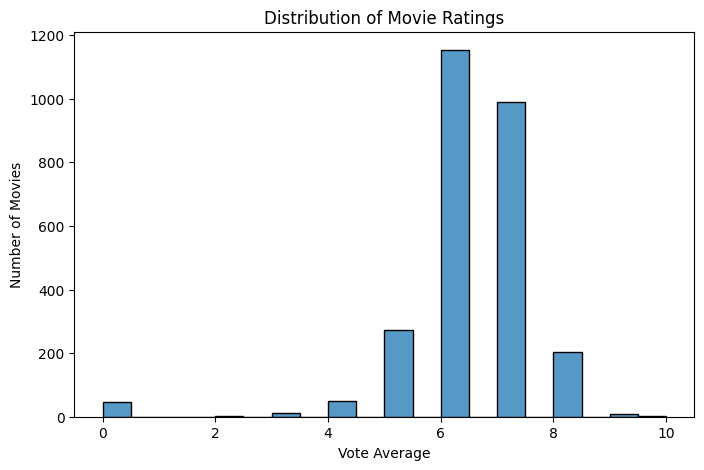

In [3]:
plt.figure(figsize=(8, 5))

sns.histplot(df["vote_average"], bins=20)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Vote Average")
plt.ylabel("Number of Movies")

plt.show()

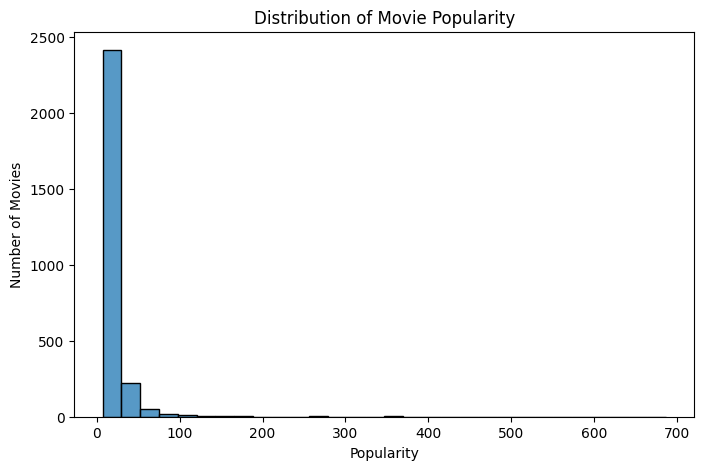

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(df["popularity"], bins=30)

plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Movies")

plt.show()

In [5]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year

In [6]:
movies_per_year = df["release_year"].value_counts().sort_index()

print(movies_per_year)

release_year
1933.0      1
1936.0      1
1938.0      1
1939.0      2
1940.0      2
         ... 
2024.0    124
2025.0    162
2026.0    314
2027.0      5
2028.0      1
Name: count, Length: 89, dtype: int64


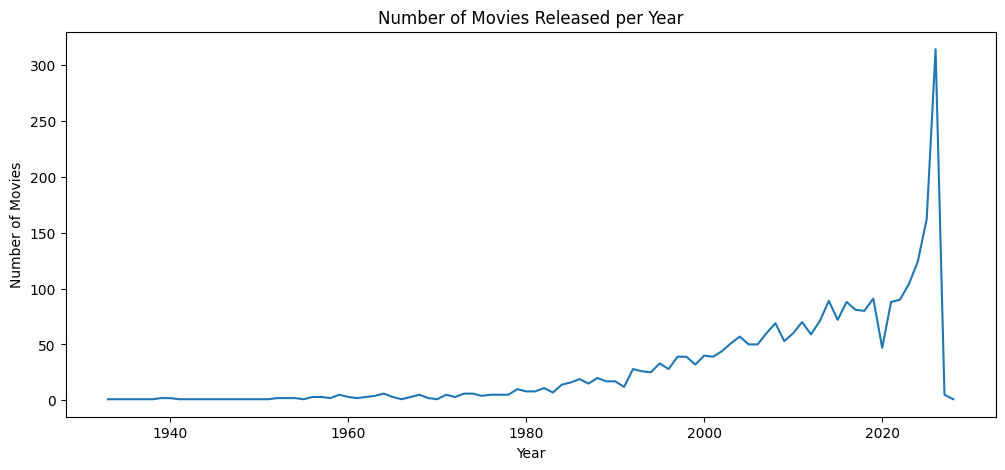

In [7]:
plt.figure(figsize=(12, 5))

movies_per_year.plot()

plt.title("Number of Movies Released per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.show()

In [8]:
genres = df.explode("genres")

print(genres[["title", "genres"]].head())

genre_counts = genres["genres"].value_counts()

print(genre_counts)

                       title           genres
0  Spider-Man: Brand New Day  Science Fiction
0  Spider-Man: Brand New Day           Action
0  Spider-Man: Brand New Day        Adventure
1              Resident Evil           Horror
1              Resident Evil  Science Fiction
genres
Drama              903
Action             881
Comedy             846
Thriller           751
Adventure          727
Science Fiction    449
Fantasy            438
Family             429
Crime              406
Horror             387
Romance            373
Animation          350
Mystery            236
History            100
War                 77
Music               50
Western             33
TV Movie            18
Documentary         12
Name: count, dtype: int64


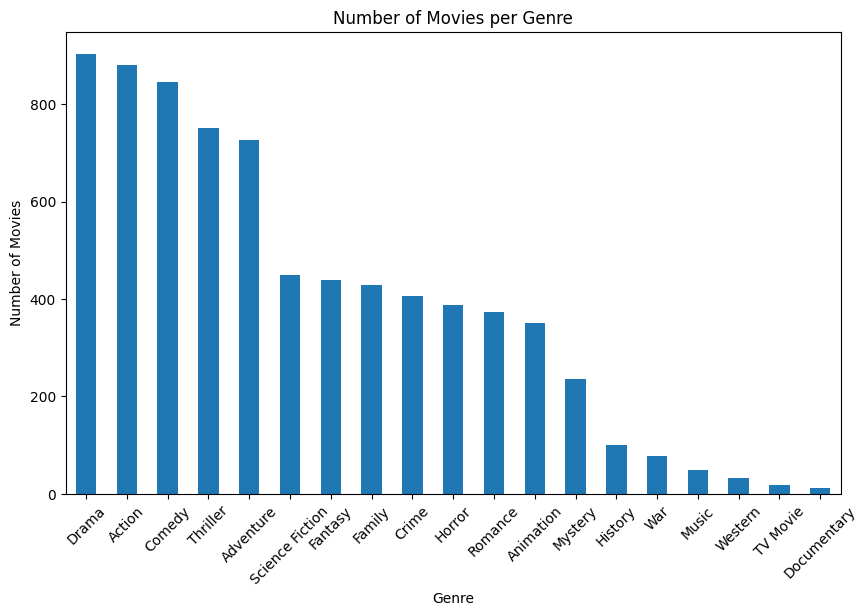

In [9]:
plt.figure(figsize=(10, 6))

genre_counts.plot(kind="bar")

plt.title("Number of Movies per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

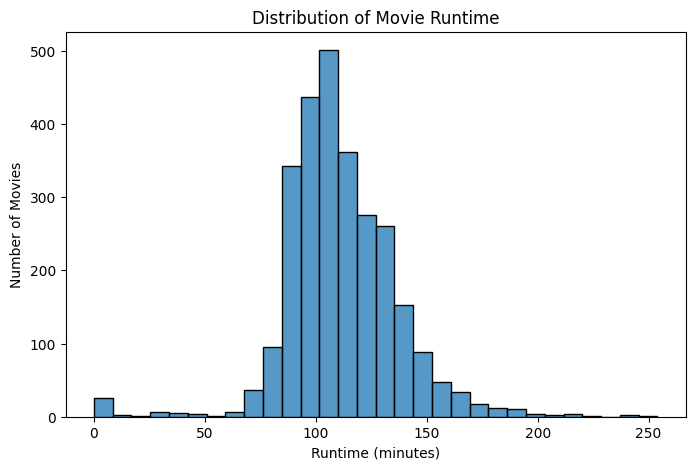

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["runtime"], bins=30)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

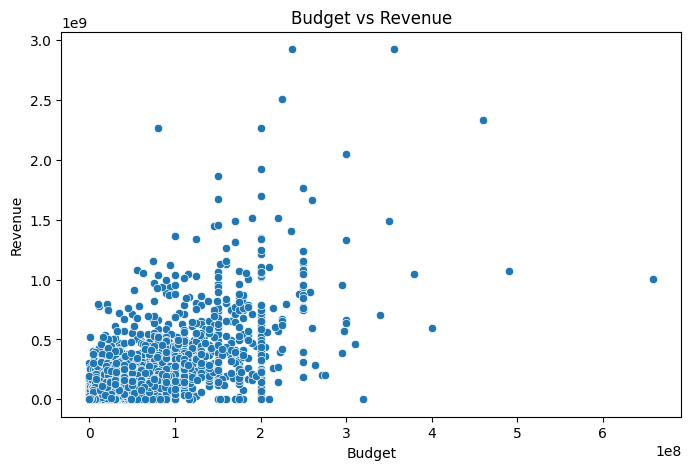

In [11]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue"
)

plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

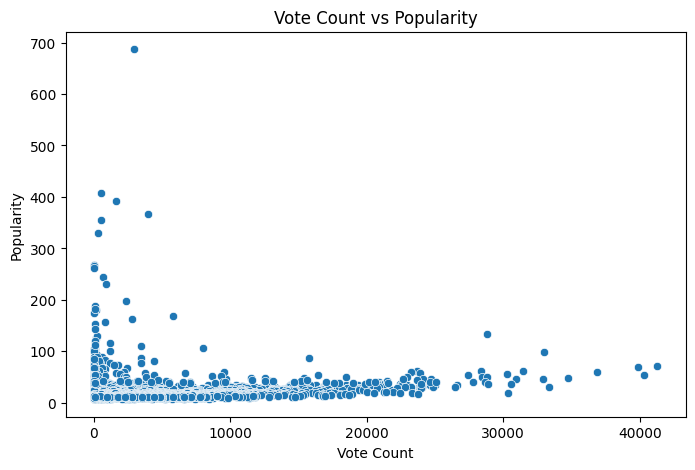

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="vote_count",
    y="popularity"
)

plt.title("Vote Count vs Popularity")
plt.xlabel("Vote Count")
plt.ylabel("Popularity")

plt.show()

               runtime    budget   revenue  popularity  vote_average  \
runtime       1.000000  0.325550  0.282704    0.057469      0.345960   
budget        0.325550  1.000000  0.680937    0.128464      0.060357   
revenue       0.282704  0.680937  1.000000    0.236163      0.160008   
popularity    0.057469  0.128464  0.236163    1.000000      0.061709   
vote_average  0.345960  0.060357  0.160008    0.061709      1.000000   
vote_count    0.321883  0.446338  0.634939    0.081568      0.320173   

              vote_count  
runtime         0.321883  
budget          0.446338  
revenue         0.634939  
popularity      0.081568  
vote_average    0.320173  
vote_count      1.000000  


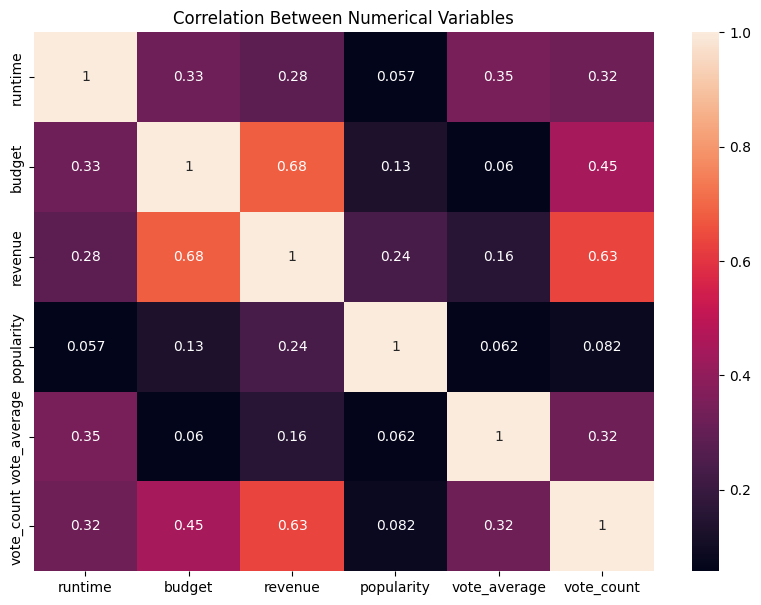

In [13]:
numeric_columns = [
    "runtime",
    "budget",
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
]

correlation = df[numeric_columns].corr()

print(correlation)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Between Numerical Variables")

plt.show()

In [14]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_decade"] = (
    df["release_year"] // 10
) * 10

df["num_genres"] = df["genres"].apply(len)
df["num_keywords"] = df["keywords"].apply(len)
df["profit"] = df["revenue"] - df["budget"]

def get_runtime_category(runtime):

    if runtime < 90:
        return "Short"

    elif runtime <= 120:
        return "Medium"

    else:
        return "Long"

df["runtime_category"] = df["runtime"].apply(get_runtime_category)
print(df.columns.tolist())

['movie_id', 'title', 'overview', 'release_date', 'runtime', 'original_language', 'genres', 'keywords', 'budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'release_year', 'release_month', 'release_decade', 'num_genres', 'num_keywords', 'profit', 'runtime_category']


In [15]:
df.to_json(
    "../data/processed/Movies_Features.json",
    orient="records",
    indent=4
)